# E-Scooter — Modèles de choix discret (Biogeme)
## Variable dépendante : accélérer (1) vs décélérer/maintenir (0)



## 1 · Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from functions_logit import run_mnl_3levels, run_mxl_panel_3levels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as Variables
import biogeme.expressions as ex
from biogeme.expressions import Beta, Variable, bioDraws, MonteCarlo, exp, log, Elem, bioNormalCdf
import biogeme.models as models
import biogeme.results_processing as rp

from biogeme.parameters import Parameters

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

DATASET_PATH = '/Volumes/My Passport/NEWMOB/clean_dataset.csv'  # meme dossier que ce notebook
FPS          = 30                   # frames par seconde
COLOR_ACC    = '#2E86AB'
COLOR_DEC    = '#E84855'


✔ Fonctions LaTeX chargées : _df_to_latex_params, _metrics_to_latex, _metrics_to_latex_mxl


## 2 · Chargement du dataset

In [2]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Dataset brut : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
print(f'Trajets      : {df_raw["source"].nunique()}')
display(df_raw.head(4))
print()
print('Valeurs manquantes :')


Dataset brut : 346,426 lignes x 77 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,...,mean_ttc_min_s,mean_drac_max_ms2,mean_reaction_time_s,mean_encounter_duration_s,mean_simultaneous_vrus,pct_unknown_interaction,pct_group_size_solo,pct_group_size_pair,pct_group_size_group_3plus,pct_group_size_unknown
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,2.548,3.099,NaN,2.567,8.148,0.0,NaN,NaN,NaN,NaN
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,2.548,3.099,NaN,2.567,8.148,0.0,NaN,NaN,NaN,NaN
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,2.548,3.099,NaN,2.567,8.148,0.0,NaN,NaN,NaN,NaN
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,2.548,3.099,NaN,2.567,8.148,0.0,NaN,NaN,NaN,NaN



Valeurs manquantes :


## 3 · Reduction a 1 Hz

Le dataset est echantillonne a 30 FPS. On regroupe par **seconde** (`second = frame // 30`) :



In [3]:
df_raw['second'] = df_raw['frame'] // FPS

df_1hz = (
    df_raw
    .groupby(['source', 'second'])
    .agg(
        speed_kmh         = ('speed_kmh',          'mean'),
        rider_id          = ('rider_id',           'first'),
        n_pedestrians     = ('n_pedestrians',       'max'),
       # distance_smooth_m = ('distance_smooth_m',   'min'),
        road_width_perp_m = ('road_width_perp_m',   'mean'),
        # ── Variables temporelles (constantes par trajet → first) ──────────
        hour              = ('hour',                'first'),
        day_of_week       = ('day_of_week',         'first'),
        day_name          = ('day_name',            'first'),
        is_weekend        = ('is_weekend',          'first'),
        time_of_day       = ('time_of_day',         'first'),
        month             = ('month',               'first'),
        season            = ('season',              'first'),
        genre             = ('genre',               'first'),
        age               = ('age',                 'first'),
        experience        = ('experience',          'first'),
        distance_km      = ('distance_km',        'first'),
        prop_vru_pedestrian = ('prop_vru_pedestrian', 'first'),
        prop_vru_cyclist   = ('prop_vru_cyclist',   'first'),
        prop_interaction_same_direction = ('prop_interaction_same_direction', 'max'),
        prop_interaction_opposite_direction = ('prop_interaction_opposite_direction', 'max'),
        prop_interaction_crossing = ('prop_interaction_crossing', 'max'),
        prop_interaction_stationary = ('prop_interaction_stationary', 'max'),
        start_crossing = ('start_crossing', 'first'),
        n_elderly = ('n_elderly', 'max'),
        n_children = ('n_children', 'max'),
        n_running = ('n_running', 'max'),
        n_crossing = ('n_crossing', 'max'),
        n_pedestrians_crossing = ('n_pedestrians_crossing', 'max'),
        n_pedestrians_opposite = ('n_pedestrians_opposite', 'max'),
        n_cyclists_crossing = ('n_cyclists_crossing', 'max'),

    )
    .reset_index()
    .sort_values(['source', 'second'])
    .reset_index(drop=True)
)

df_1hz['speed_kmh_t1'] = df_1hz.groupby('source')['speed_kmh'].shift(-1)

print(f'Après réduction 1 Hz : {len(df_1hz):,} secondes — {df_1hz["source"].nunique()} trajets')
display(df_1hz.describe().round(2))

Après réduction 1 Hz : 1,271 secondes — 25 trajets


,second,speed_kmh,n_pedestrians,road_width_perp_m,hour,day_of_week,month,age,distance_km,prop_vru_pedestrian,...,prop_interaction_stationary,start_crossing,n_elderly,n_children,n_running,n_crossing,n_pedestrians_crossing,n_pedestrians_opposite,n_cyclists_crossing,speed_kmh_t1
count,1271.00,1242.00,1271.00,1242.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,...,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1218.00
mean,52.50,14.85,3.39,16.53,10.66,3.15,6.83,37.79,143.82,0.89,...,0.11,0.02,0.25,0.11,0.44,0.44,0.43,1.40,0.01,14.90
std,45.67,7.52,2.78,13.72,3.56,1.43,2.36,12.45,90.17,0.29,...,0.25,0.14,0.56,0.39,1.50,1.01,1.01,1.63,0.09,7.56
min,0.00,2.02,0.00,0.04,5.00,0.00,4.00,21.00,10.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.02
25%,15.50,9.29,1.00,8.04,6.00,2.00,5.00,29.00,55.69,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.29
50%,39.00,12.13,3.00,11.05,10.00,3.00,6.00,30.00,142.27,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,12.15
75%,77.00,20.71,5.00,22.62,13.00,4.00,10.00,53.00,239.34,1.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,0.00,20.91
max,202.00,33.85,14.00,102.76,20.00,6.00,10.00,55.00,323.21,1.00,...,1.00,1.00,5.00,3.00,13.00,8.00,8.00,8.00,1.00,33.85


In [4]:
df_1hz

,source,second,speed_kmh,rider_id,n_pedestrians,road_width_perp_m,hour,day_of_week,day_name,is_weekend,...,prop_interaction_stationary,start_crossing,n_elderly,n_children,n_running,n_crossing,n_pedestrians_crossing,n_pedestrians_opposite,n_cyclists_crossing,speed_kmh_t1
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,6,11.704180,332t_vague2,1,40.648818,10,2,Wednesday,False,...,0.000000,1,0,0,0,1,1,0,0,11.549013
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,7,11.549013,332t_vague2,5,35.868515,10,2,Wednesday,False,...,0.250000,0,1,1,0,1,1,2,0,11.360816
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,8,11.360816,332t_vague2,5,37.532316,10,2,Wednesday,False,...,0.400000,0,1,1,0,0,0,2,0,11.020953
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,9,11.020953,332t_vague2,2,43.802357,10,2,Wednesday,False,...,0.000000,0,1,0,0,0,0,1,0,10.688393
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,10,10.688393,332t_vague2,4,34.699007,10,2,Wednesday,False,...,0.333333,0,1,0,0,0,0,1,0,10.527781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,392t_2023-05-05 15_09_07_392t_0_52_3_42,139,5.843781,392t_vague2,7,29.527322,13,4,Friday,False,...,0.500000,0,0,1,0,1,1,1,0,5.638858
1267,392t_2023-05-05 15_09_07_392t_0_52_3_42,140,5.638858,392t_vague2,6,25.078764,13,4,Friday,False,...,0.500000,0,0,0,0,2,2,0,0,5.518513
1268,392t_2023-05-05 15_09_07_392t_0_52_3_42,141,5.518513,392t_vague2,2,24.312392,13,4,Friday,False,...,0.000000,0,0,0,0,1,1,0,0,5.363098
1269,392t_2023-05-05 15_09_07_392t_0_52_3_42,142,5.363098,392t_vague2,1,23.473762,13,4,Friday,False,...,0.000000,0,0,0,0,0,0,0,0,5.354880


## 4 · Variable dependante : acceleration/deceleration


Observations totales : 1,178
  Décélérer  : 233  (19.8 %)
  Maintenir  : 661  (56.1 %)
  Accélérer  : 284  (24.1 %)


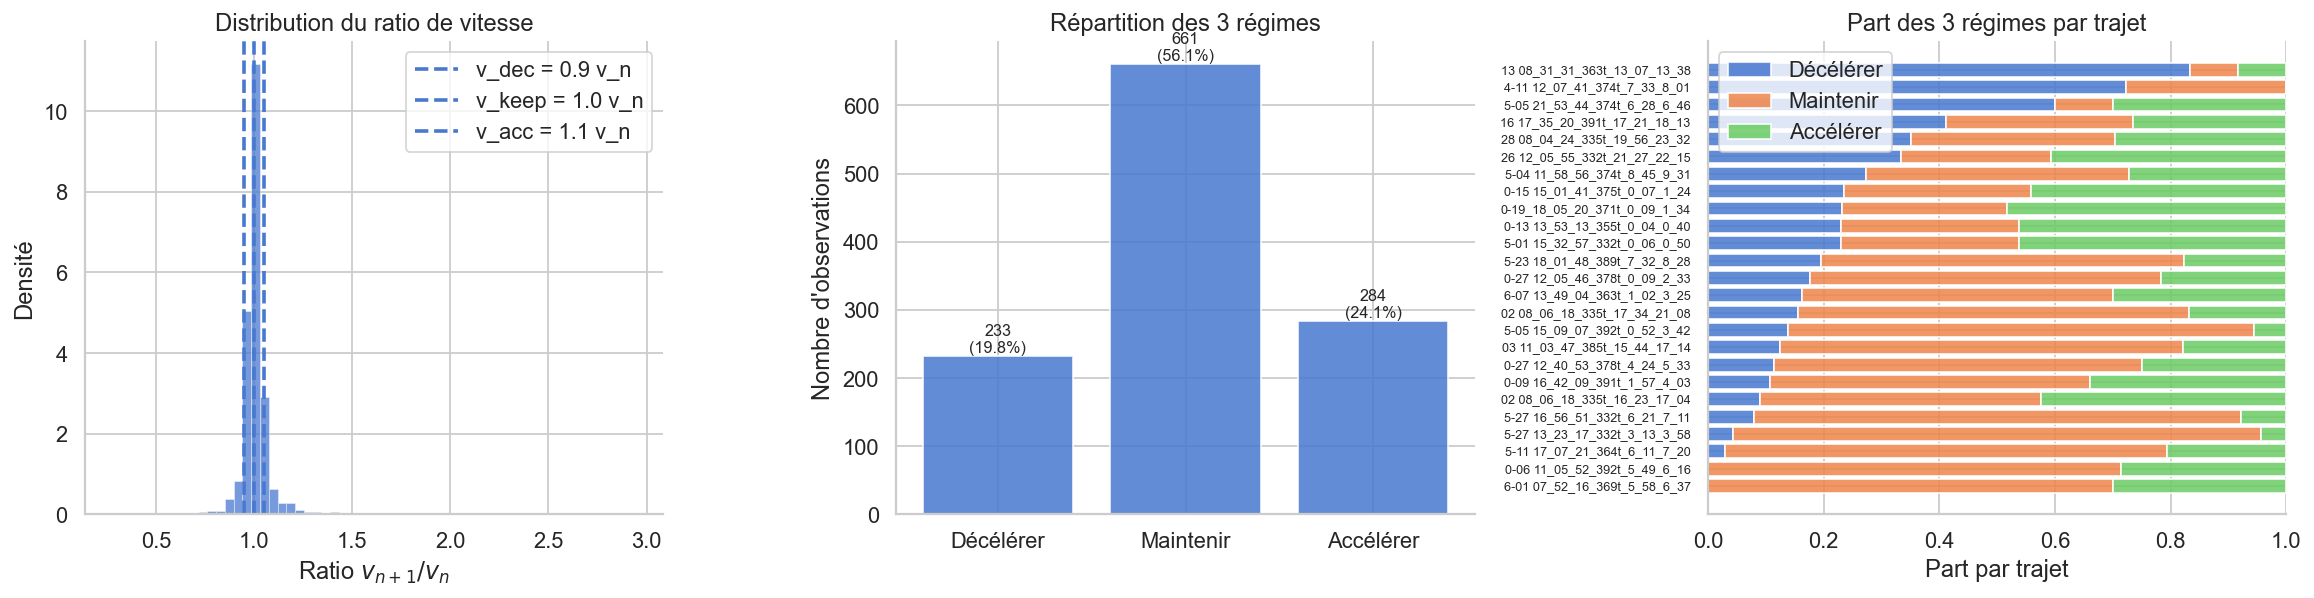

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètre du modèle
c = 0.05

# Vitesse à t+1
df_1hz['speed_next'] = df_1hz.groupby('source')['speed_kmh_t1'].shift(-1)

# Base modèle
df_model = df_1hz.dropna(subset=[
    'speed_next', 'speed_kmh_t1'
]).copy()

# On évite les vitesses négatives éventuelles
df_model = df_model[df_model['speed_kmh'] >= 0].copy()

df_model['rider_id_num'], rider_mapping = pd.factorize(df_model['rider_id'])
df_model['rider_id_num'] = df_model['rider_id_num'] + 1

# Vitesses théoriques des 3 régimes
df_model['v_dec']  = (1 - c) * df_model['speed_kmh_t1']   
df_model['v_keep'] = df_model['speed_kmh_t1']            
df_model['v_acc']  = (1 + c) * df_model['speed_kmh_t1']  

# Distance entre la vitesse observée suivante et chacun des 3 régimes
dist_dec  = (df_model['speed_next'] - df_model['v_dec']).abs()
dist_keep = (df_model['speed_next'] - df_model['v_keep']).abs()
dist_acc  = (df_model['speed_next'] - df_model['v_acc']).abs()

# Choix multinomial :
# 0 = decelerer, 1 = maintenir, 2 = accelerer
df_model['choice_3'] = np.argmin(
    np.vstack([dist_dec, dist_keep, dist_acc]),
    axis=0
)

label_map = {
    0: 'Décélérer',
    1: 'Maintenir',
    2: 'Accélérer'
}
df_model['choice_3_label'] = df_model['choice_3'].map(label_map)

# Comptages
counts = df_model['choice_3'].value_counts().sort_index()
n_total = len(df_model)

print(f'Observations totales : {n_total:,}')
for k, lab in label_map.items():
    n_k = counts.get(k, 0)
    print(f'  {lab:10s} : {n_k:,}  ({100*n_k/n_total:.1f} %)')

df_model['speed_ratio'] = df_model['speed_next'] / df_model['speed_kmh_t1']
# =========================
# PLOTS
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# -------- Plot 1 : histogramme du ratio v_{n+1} / v_n --------
ax = axes[0]

ratio_plot = df_model['speed_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
ratio_plot = ratio_plot[(ratio_plot >= 0) & (ratio_plot <= 3)]  # coupe visuelle optionnelle

ax.hist(ratio_plot, bins=60, alpha=0.75, edgecolor='white', lw=0.3, density=True)
ax.axvline(1 - c, lw=2, ls='--', label=f'v_dec = {(1-c):.1f} v_n')
ax.axvline(1.0,   lw=2, ls='--', label='v_keep = 1.0 v_n')
ax.axvline(1 + c, lw=2, ls='--', label=f'v_acc = {(1+c):.1f} v_n')

ax.set_xlabel(r'Ratio $v_{n+1} / v_n$')
ax.set_ylabel('Densité')
ax.set_title('Distribution du ratio de vitesse')
ax.legend()

# -------- Plot 2 : parts globales des 3 choix --------
ax = axes[1]

vals = [counts.get(0, 0), counts.get(1, 0), counts.get(2, 0)]
labs = [label_map[0], label_map[1], label_map[2]]

bars = ax.bar(labs, vals, alpha=0.85)
ax.set_ylabel("Nombre d'observations")
ax.set_title('Répartition des 3 régimes')

for i, v in enumerate(vals):
    ax.text(i, v, f'{v:,}\n({100*v/n_total:.1f}%)', ha='center', va='bottom', fontsize=9)

# -------- Plot 3 : parts par trajet (stacked) --------
ax = axes[2]

share = (
    df_model
    .groupby('source')['choice_3']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# S'assurer que les 3 colonnes existent
for k in [0, 1, 2]:
    if k not in share.columns:
        share[k] = 0.0

share = share[[0, 1, 2]].sort_values(by=[0, 1, 2])

y = np.arange(len(share))
ax.barh(y, share[0], alpha=0.85, label='Décélérer')
ax.barh(y, share[1], left=share[0], alpha=0.85, label='Maintenir')
ax.barh(y, share[2], left=share[0] + share[1], alpha=0.85, label='Accélérer')

ax.set_yticks(y)
ax.set_yticklabels([s[-28:] for s in share.index], fontsize=7)
ax.set_xlabel('Part par trajet')
ax.set_title('Part des 3 régimes par trajet')
ax.legend()

plt.tight_layout()
plt.show()

## Desc stats

Variable                            Test                   H / χ²    p-value   Sig.
experience                          Chi² (df=6)             30.07    0.00004    ***
time_of_day                         Chi² (df=6)             19.60    0.00326     **
season                              Chi² (df=4)             19.46    0.00064    ***
genre                               Chi² (df=2)              8.35    0.01537      *
is_weekend                          Chi² (df=2)              6.92    0.03149      *


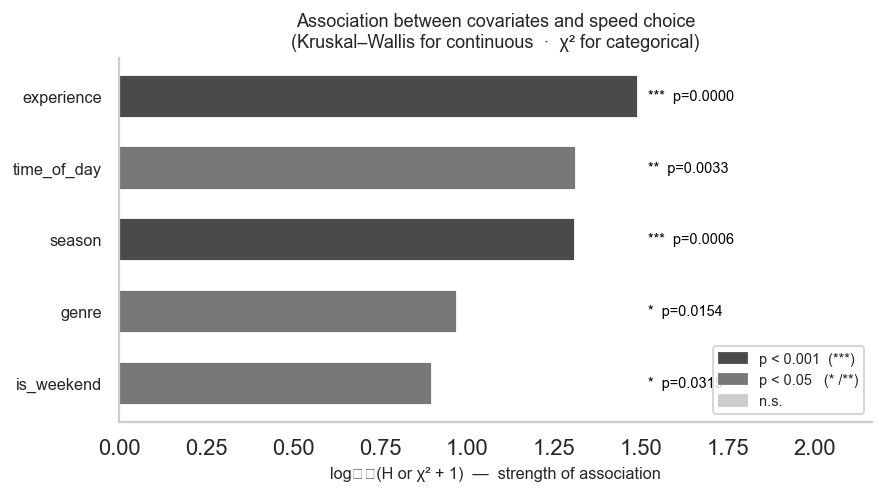

In [6]:

# ── Contingency table : association entre chaque variable et le choix ─────────
import pandas as pd
import numpy as np
from scipy import stats

CHOICE_COL = 'choice_3_label'
choices    = [c for c in ['Decelerate', 'Maintain', 'Accelerate']
              if c in df_model[CHOICE_COL].values]

cont_vars = ['z_speed_kmh_t1', 'n_pedestrians', 'road_width_perp_m',
             'age', 'hour', 'prop_vru_pedestrian', 'prop_vru_cyclist',
             'prop_interaction_same_direction']
cat_vars  = ['genre', 'experience', 'time_of_day', 'is_weekend', 'season']
cont_vars = [v for v in cont_vars if v in df_model.columns]
cat_vars  = [v for v in cat_vars  if v in df_model.columns]

rows = []

# ── Variables continues : Kruskal-Wallis ──────────────────────────────────────
for v in cont_vars:
    groups = [df_model.loc[df_model[CHOICE_COL] == c, v].dropna() for c in choices]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    stat, p = stats.kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    means = {c: df_model.loc[df_model[CHOICE_COL]==c, v].mean() for c in choices}
    rows.append({'Variable': v, 'Type': 'continuous', 'Test': 'Kruskal-Wallis',
                 **{f'mean_{c}': round(means[c], 3) for c in choices},
                 'H-stat': round(stat, 2), 'p-value': round(p, 5), 'Sig.': sig})

# ── Variables catégorielles : Chi² ────────────────────────────────────────────
for v in cat_vars:
    ct = pd.crosstab(df_model[v], df_model[CHOICE_COL])
    if ct.shape[0] < 2:
        continue
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    modes = {}
    for c in choices:
        sub = df_model.loc[df_model[CHOICE_COL]==c, v].dropna()
        if len(sub):
            vc = sub.value_counts()
            modes[f'mean_{c}'] = f"{vc.index[0]} ({vc.iloc[0]/len(sub)*100:.0f}%)"
        else:
            modes[f'mean_{c}'] = '—'
    rows.append({'Variable': v, 'Type': 'categorical', 'Test': f'Chi² (df={dof})',
                 **modes, 'H-stat': round(chi2, 2), 'p-value': round(p, 5), 'Sig.': sig})

df_stats = pd.DataFrame(rows).set_index('Variable')
df_stats = df_stats.sort_values('H-stat', ascending=False)

# ── Affichage tableau résumé ───────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 20)

print("=" * 100)
print(f"{'Variable':<35} {'Test':<20} {'H / χ²':>8}  {'p-value':>9}  {'Sig.':>5}")
print("=" * 100)
for v, row in df_stats.iterrows():
    print(f"{v:<35} {row['Test']:<20} {row['H-stat']:>8.2f}  {row['p-value']:>9.5f}  {row['Sig.']:>5}")
print("=" * 100)

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_plot = df_stats.sort_values('H-stat', ascending=True)
log_stat = np.log10(df_plot['H-stat'].astype(float) + 1)
ys = np.arange(len(df_plot))

colors = ['#4a4a4a' if s == '***' else '#777777' if s in ('**','*') else '#cccccc'
          for s in df_plot['Sig.']]

fig, ax = plt.subplots(figsize=(7, len(df_plot) * 0.5 + 1.5))
ax.barh(ys, log_stat.values, color=colors, edgecolor='white', height=0.6)
ax.set_yticks(ys)
ax.set_yticklabels(df_plot.index, fontsize=9)
ax.set_xlabel('log₁₀(H or χ² + 1)  —  strength of association', fontsize=9)
ax.set_title('Association between covariates and speed choice\n'
             '(Kruskal–Wallis for continuous  ·  χ² for categorical)', fontsize=10)

for y, (_, row) in zip(ys, df_plot.iterrows()):
    ax.text(log_stat.max() * 1.02, y, f"{row['Sig.']}  p={row['p-value']:.4f}",
            va='center', ha='left', fontsize=8,
            color='black' if row['Sig.'] != 'n.s.' else '#aaa')

ax.set_xlim(0, log_stat.max() * 1.45)
ax.grid(False)

legend = [Patch(color='#4a4a4a', label='p < 0.001  (***)'),
          Patch(color='#777777', label='p < 0.05   (* /**)'),
          Patch(color='#cccccc', label='n.s.')]
ax.legend(handles=legend, fontsize=8, framealpha=0.85, loc='lower right')

plt.tight_layout()
fig.savefig("contingency_overview.pdf", dpi=300, bbox_inches="tight")
fig.savefig("contingency_overview.png", dpi=300, bbox_inches="tight")
plt.show()


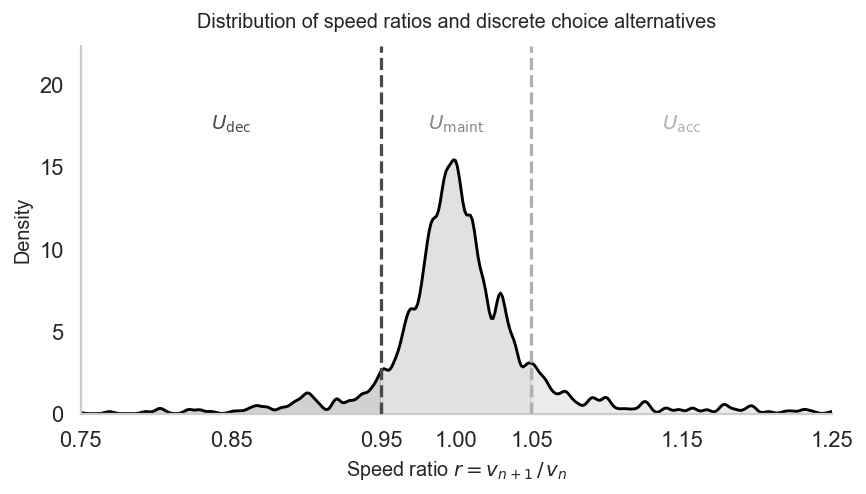

Saved: speed_ratio_plot.pdf / .png


In [7]:

# ── Publication-quality plot : distribution du ratio v_{n+1} / v_n ────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Thresholds
T_DEC  = 0.95
T_KEEP = 1.0
T_ACC  = 1.05

# Palette de gris
C_DEC  = "#4a4a4a"
C_KEEP = "#888888"
C_ACC  = "#b0b0b0"

ratio = df_model["speed_ratio"].dropna()
ratio = ratio[(ratio >= 0.5) & (ratio <= 1.5)]

# KDE
kde     = gaussian_kde(ratio, bw_method=0.04)
x_grid  = np.linspace(0.5, 1.5, 800)
density = kde(x_grid)

# Frontières des zones
mid1 = T_DEC  # 0.975
mid2 = T_ACC# 1.025

X_MIN, X_MAX = 0.75, 1.25

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.fill_between(x_grid, density,
                where=(x_grid <= mid1),
                color=C_DEC,  alpha=0.25, label="_nolegend_")
ax.fill_between(x_grid, density,
                where=(x_grid > mid1) & (x_grid <= mid2),
                color=C_KEEP, alpha=0.25, label="_nolegend_")
ax.fill_between(x_grid, density,
                where=(x_grid > mid2),
                color=C_ACC,  alpha=0.25, label="_nolegend_")

# Courbe KDE
ax.plot(x_grid, density, color="black", lw=1.6)

ymax = density.max()

# ── Lignes verticales aux seuils ──────────────────────────────────────────────
for x, color in [(T_DEC, C_DEC), (T_ACC, C_ACC)]:
    ax.axvline(x, color=color, lw=1.8, ls="--", zorder=3)

# ── Labels centrés dans chaque zone ──────────────────────────────────────────
zone_labels = [
    ((X_MIN + mid1) / 2,  C_DEC,  r"$U_{\mathrm{dec}}$"),
    ((mid1 + mid2) / 2,   C_KEEP, r"$U_{\mathrm{maint}}$"),
    ((mid2 + X_MAX) / 2,  C_ACC,  r"$U_{\mathrm{acc}}$"),
]
for x_center, color, label in zone_labels:
    ax.text(x_center, ymax * 1.10, label,
            ha="center", va="bottom",
            fontsize=11, color=color, fontweight="bold")

# ── Axes & labels ─────────────────────────────────────────────────────────────
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, ymax * 1.45)
ax.set_xlabel(r"Speed ratio $r = v_{n+1} \,/\, v_n$", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(r"Distribution of speed ratios and discrete choice alternatives",
             fontsize=11, pad=10)

legend_handles = [
    mpatches.Patch(facecolor=C_DEC,  alpha=0.6, label="Decelerate"),
    mpatches.Patch(facecolor=C_KEEP, alpha=0.6, label="Maintain"),
    mpatches.Patch(facecolor=C_ACC,  alpha=0.6, label="Accelerate"),
]
#ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
         # framealpha=0.85, edgecolor="lightgrey")

ax.set_xticks([0.75, 0.85, 0.95, 1.0, 1.05, 1.15, 1.25])
ax.grid(False)

sns.despine(ax=ax)
fig.tight_layout()
fig.savefig("speed_ratio_plot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("speed_ratio_plot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: speed_ratio_plot.pdf / .png")


## 5 · Standardisation & création de dummy

**Variables standardisees** (`z = (x - mu) / sigma`) : coefficients comparables.


In [ ]:
# ── Variables continues : z-scores ───────────────────────────────────────────
cont_vars = [
    # variables existantes
    'speed_kmh', 'n_pedestrians', 'road_width_perp_m',
    'age', 'hour', 'prop_vru_pedestrian', 'prop_vru_cyclist',
    'prop_interaction_same_direction',
    # nouvelles variables annotées (comptages VRU)
    'n_elderly',
    'n_children',
    'n_running',
    'n_groups',
    'n_crossing',
    'n_pedestrians_crossing',
    'n_pedestrians_opposite',
    'n_cyclists_crossing',
    # cinématique rencontre
    'mean_peak_decel_ms2',
    'mean_ttc_min_s',
    'mean_drac_max_ms2',
    'mean_reaction_time_s',
    'mean_encounter_duration_s',
    'mean_simultaneous_vrus',
    # intersection
    'at_intersection',
]

cont_vars = [
    v for v in cont_vars
    if v in df_model.columns and df_model[v].notna().any()
]

means_ = df_model[cont_vars].mean()
stds_  = df_model[cont_vars].std()

for v in cont_vars:
    if pd.notna(stds_[v]) and stds_[v] != 0:
        df_model[f'z_{v}'] = (df_model[v] - means_[v]) / stds_[v]
    else:
        df_model[f'z_{v}'] = 0.0
        print(f'  ⚠  {v} a un écart-type nul → z_{v}=0 pour toutes les lignes')

print('Statistiques des z-scores (doivent être ~mean=0, std=1) :')
display(df_model[[f'z_{v}' for v in cont_vars]].describe().round(3))


# ── Variables catégorielles contextuelles (weather, lighting, etc.) ──────────
context_cat_vars = [
    'WEATHER_LABEL',
    'LIGHTING_LABEL',
    'SURFACE_CONDITION_LABEL',
    'ZONE_TYPE_LABEL',
    'VISUAL_SEGREGATION_LABEL',
    'RIDING_COMPANION_LABEL',
]
context_cat_vars = [v for v in context_cat_vars if v in df_model.columns
                    and df_model[v].notna().any()]
print(f'\nVariables contextuelles annotées disponibles : {context_cat_vars}')


# ── Variables catégorielles : toutes les non-continues ───────────────────────
exclude_from_cat = set(cont_vars)
exclude_from_cat.update([f'z_{v}' for v in cont_vars])
exclude_from_cat.update([
    'source',
    'rider_id_num',
])

candidate_cat_vars = [
    c for c in df_model.columns
    if c not in exclude_from_cat
]

cat_vars = []

for col in candidate_cat_vars:
    s = df_model[col]

    if s.notna().sum() == 0:
        continue

    if (
        pd.api.types.is_object_dtype(s)
        or pd.api.types.is_categorical_dtype(s)
        or pd.api.types.is_bool_dtype(s)
    ):
        cat_vars.append(col)

    elif pd.api.types.is_numeric_dtype(s):
        nunique = s.dropna().nunique()
        if nunique <= 10:
            cat_vars.append(col)

print('\nVariables catégorielles détectées automatiquement :')
print(cat_vars)


# ── Dummies catégorielles avec référence = modalité la plus fréquente ────────
categorical_dummy_cols = []
ref_levels = {}

for col in cat_vars:
    s = df_model[col]

    if s.notna().sum() == 0:
        print(f'  ⚠  {col} entièrement vide — ignoré')
        continue

    vc = s.value_counts(dropna=True)
    if vc.empty:
        print(f'  ⚠  {col} sans valeur exploitable — ignoré')
        continue

    ref = vc.index[0]
    ref_levels[col] = ref

    uniq = s.dropna().unique().tolist()
    remaining = [v for v in uniq if v != ref]
    try:
        remaining = sorted(remaining)
    except Exception:
        remaining = [str(v) for v in remaining]
        ref = str(ref)
        s = s.astype(str).where(s.notna(), np.nan)

    cats = [ref] + remaining

    dummies = pd.get_dummies(
        pd.Categorical(s, categories=cats, ordered=False),
        prefix=col,
        drop_first=True
    )
    dummies = dummies.astype(int)

    df_model = pd.concat(
        [df_model.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )
    categorical_dummy_cols.extend(dummies.columns.tolist())

    print(
        f'  {col:35s} → {len(dummies.columns)} dummies  '
        f'(réf = {ref!r}, n={vc.iloc[0]})  |  {dummies.columns.tolist()}'
    )

print(f'\nDummies catégorielles ajoutées : {len(categorical_dummy_cols)}')

# ── Récapitulatif ─────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('Récapitulatif des blocs de variables')
print('=' * 60)
print(f'  Variables continues     : {cont_vars}')
print(f'  Variables contextuelles : {context_cat_vars}')
print(f'  Total colonnes modèle   : {df_model.shape[1]}')
print(f'  Total lignes            : {df_model.shape[0]}')

## Betas and variables

In [9]:
import re
from biogeme.expressions import Variable, Beta

def normalize(name: str) -> str:
    clean = name.lower()
    clean = re.sub(r'[^a-z0-9]+', '_', clean)
    clean = re.sub(r'_+', '_', clean)
    clean = clean.strip('_')
    if re.match(r'^[0-9]', clean):
        clean = "var_" + clean
    return clean

# dummies + continues standardisées
continuous_model_cols = [f"z_{v}" for v in cont_vars if f"z_{v}" in df_model.columns]
model_cols = categorical_dummy_cols.copy() + continuous_model_cols

print("Variables catégorielles :", categorical_dummy_cols)
print("Variables continues     :", continuous_model_cols)
print("Total variables modèle  :", len(model_cols))

created_variables = []
created_betas_dec = []
created_betas_acc = []

for col in model_cols:
    clean_name = normalize(col)

    if clean_name == "":
        print(f"Skip (empty after cleaning): {col}")
        continue

    if not clean_name.isidentifier():
        print(f"Skip (invalid identifier): {clean_name} ← {col}")
        continue

    # Variable Biogeme
    if clean_name not in globals():
        globals()[clean_name] = Variable(col)
        created_variables.append(clean_name)

    # Beta pour DECELERER
    beta_name_dec = f"beta_{clean_name}_dec"
    if not beta_name_dec.isidentifier():
        print(f"Skip beta dec (invalid identifier): {beta_name_dec}")
    elif beta_name_dec not in globals():
        globals()[beta_name_dec] = Beta(beta_name_dec, 0, None, None, 0)
        created_betas_dec.append(beta_name_dec)

    # Beta pour ACCELERER
    beta_name_acc = f"beta_{clean_name}_acc"
    if not beta_name_acc.isidentifier():
        print(f"Skip beta acc (invalid identifier): {beta_name_acc}")
    elif beta_name_acc not in globals():
        globals()[beta_name_acc] = Beta(beta_name_acc, 0, None, None, 0)
        created_betas_acc.append(beta_name_acc)

print(f"\n✔ Variables Biogeme créées : {len(created_variables)}")
print(created_variables)

print(f"\n✔ Betas _dec créés : {len(created_betas_dec)}")
print(created_betas_dec)

print(f"\n✔ Betas _acc créés : {len(created_betas_acc)}")
print(created_betas_acc)

Variables catégorielles : ['rider_id_332t_vague2', 'rider_id_355t_vague1', 'rider_id_363t_vague2', 'rider_id_364t_vague2', 'rider_id_369t_vague2', 'rider_id_371t_vague3', 'rider_id_374t_vague2', 'rider_id_375t_vague1', 'rider_id_378t_vague1', 'rider_id_385t_vague3', 'rider_id_389t_vague2', 'rider_id_391t_vague1', 'rider_id_391t_vague2', 'rider_id_392t_vague1', 'rider_id_392t_vague2', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_5', 'day_of_week_6', 'day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'is_weekend_True', 'time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night', 'month_4', 'month_5', 'month_6', 'season_Autumn', 'season_Summer', 'genre_male', 'experience_0.5-1', 'experience_1-2', 'experience_<0.5', 'start_crossing_1', 'choice_3_0', 'choice_3_2', 'choice_3_label_Accélérer', 'choice_3_label_Décélérer']
Variables continues     : ['z_speed_kmh', 'z_n_pedestrians'

## 9 · Modele 2 — + Largeur de route


In [10]:
# ── M3 : piétons + variables socio-démo ─────────────────────────────────────
all_metrics = []
all_params = {}
all_res = {}
# ASC pour les deux alternatives estimées
ASC_DEC = ex.Beta('ASC_DEC', 0, None, None, 0)
ASC_ACC = ex.Beta('ASC_ACC', 0, None, None, 0)

# ── Utilité décélérer (vs maintenir) ────────────────────────────────────────
U_dec_M3 = (
    ASC_DEC
   # + beta_z_prop_vru_pedestrian_dec * z_prop_vru_pedestrian
  #  + beta_z_n_pedestrians_dec * z_n_pedestrians
    # + beta_z_prop_interaction_same_direction_dec * z_prop_interaction_same_direction
   # + beta_genre_female_dec * genre_female
   # + beta_experience_0_5_dec * experience_0_5
  #  + beta_experience_0_5_1_dec * experience_0_5_1
  #  + beta_experience_1_2_dec * experience_1_2
   # + beta_z_age_dec * z_age
   # + beta_start_crossing_1_dec * start_crossing_1
#  + beta_genre_female_dec * genre_female
   #    + beta_z_road_width_perp_m_dec * z_road_width_perp_m
    + beta_z_n_pedestrians_crossing_dec * z_n_pedestrians_crossing

)

# ── Utilité accélérer (vs maintenir) ────────────────────────────────────────
U_acc_M3 = (
    ASC_ACC
#   + beta_z_prop_vru_pedestrian_acc * z_prop_vru_pedestrian
   #  + beta_z_n_pedestrians_acc * z_n_pedestrians
    # + beta_z_prop_interaction_same_direction_acc * z_prop_interaction_same_direction
   # + beta_genre_female_acc * genre_female
    + beta_experience_0_5_acc * experience_0_5
   #+ beta_experience_0_5_1_acc * experience_0_5_1
  #  + beta_experience_1_2_acc * experience_1_2
    #+ beta_z_age_acc * z_age
    #+ beta_start_crossing_1_acc * start_crossing_1
    + beta_genre_male_acc * genre_male
    + beta_z_n_pedestrians_crossing_acc * z_n_pedestrians_crossing
  #  + beta_z_road_width_perp_m_acc * z_road_width_perp_m
)

res3, p3, m3, _ = run_mnl_3levels(
    df_est=df_model,
    utility_decelerate=U_dec_M3,
    utility_accelerate=U_acc_M3,
    model_name='M3_ped_dist',
    choice_col='choice_3'
)

all_metrics.append(m3)
all_params['M3_ped_dist'] = p3
all_res['M3_ped_dist'] = res3


Betas sans mapping explicite dans BETA_LABELS :
   'beta_genre_male_acc'

  Modèle constant  (M3_ped_dist_constant)
  LL=-1163.54  rho2_null=0.1009  rho2bar_null=0.0994  rho2_const=0.0000  rho2bar_const=-0.0017  AIC=2331.1  BIC=2341.2
──────────────────────────────────────────────────────────────────────────────────────────
  Modèle principal (M3_ped_dist)
  N=1178  K=6  LL=-1144.11  rho2_null=0.1159  rho2bar_null=0.1113  rho2_const=0.0167  rho2bar_const=0.0115  AIC=2300.2  BIC=2330.6
──────────────────────────────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(4)=38.87  p=0.0000 ***


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC_DEC,-1.0676,0.0774,-13.789,0.0000
1,beta_z_n_pedestrians_crossing_dec,0.2705,0.0622,4.352,0.0000
2,ASC_ACC,-1.2246,0.1272,-9.627,0.0000
3,beta_experience_0_5_acc,0.6001,0.1618,3.709,0.0002
4,beta_genre_male_acc,0.4052,0.1476,2.746,0.0060
5,beta_z_n_pedestrians_crossing_acc,-0.0753,0.1139,-0.661,0.5087


## Mixed model

In [12]:
# ── M3 mixed logit panel : 2 random effects dans l'erreur ──────────────────
all_metrics = []
all_params = {}
all_res = {}

# ASC fixes
ASC_DEC = ex.Beta('ASC_DEC', 0, None, None, 0)
ASC_ACC = ex.Beta('ASC_ACC', 0, None, None, 0)

# Ecart-types des composantes aléatoires
SIGMA_DEC = ex.Beta('SIGMA_DEC', 1, None, None, 0)
SIGMA_ACC = ex.Beta('SIGMA_ACC', 1, None, None, 0)

# Random effects (panel-level)
# Un tirage par individu, partagé sur toutes ses observations
ERR_DEC = SIGMA_DEC * ex.Draws('ERR_DEC', 'NORMAL')
ERR_ACC = SIGMA_ACC * ex.Draws('ERR_ACC', 'NORMAL')

# ── Utilité décélérer (vs maintenir) ────────────────────────────────────────
U_dec_M3 = (
    ASC_DEC
    + beta_z_n_pedestrians_crossing_dec * z_n_pedestrians_crossing
        #  + beta_z_road_width_perp_m_dec * z_road_width_perp_m

    + SIGMA_DEC * ex.Draws('ERR_DEC', 'NORMAL')
)

# ── Utilité accélérer (vs maintenir) ────────────────────────────────────────
U_acc_M3 = (
    ASC_ACC
    + beta_experience_0_5_acc * experience_0_5
   #+ beta_experience_0_5_1_acc * experience_0_5_1
  #  + beta_experience_1_2_acc * experience_1_2
    #+ beta_z_age_acc * z_age
    #+ beta_start_crossing_1_acc * start_crossing_1
    #+ beta_genre_male_acc * genre_male
  #  + beta_z_road_width_perp_m_acc * z_road_width_perp_m


   # + beta_genre_female_acc * genre_female
+ SIGMA_ACC * ex.Draws('ERR_ACC', 'NORMAL')
)

res3, p3, m3 = run_mxl_panel_3levels(
    df_est=df_model,
    utility_decelerate=U_dec_M3,
    utility_accelerate=U_acc_M3,
    model_name='M3_ped_dist_RE2',
    panel_id_col='rider_id_num',    
    number_of_draws=10000
)

all_metrics.append(m3)
all_params['M3_ped_dist_RE4'] = p3
all_res['M3_ped_dist_RE4'] = res3


🚀 LANCEMENT ESTIMATION : M3_ped_dist_RE2
[M3_ped_dist_RE2] Étape 1/6 - Extraction des variables des utilités
[M3_ped_dist_RE2] Variables utilité décélérer : ['z_n_pedestrians_crossing']
[M3_ped_dist_RE2] Variables utilité accélérer : ['experience_<0.5']
[M3_ped_dist_RE2] Colonnes retenues : ['rider_id_num', 'choice_3', 'z_n_pedestrians_crossing', 'experience_<0.5']
[M3_ped_dist_RE2] Nombre de lignes avant nettoyage : 1,178
[M3_ped_dist_RE2] Aucune ligne supprimée pour NaN
[M3_ped_dist_RE2] Conversion des booléens en entiers si nécessaire
[M3_ped_dist_RE2] Aucun choix invalide supprimé
[M3_ped_dist_RE2] Tri des données par identifiant panel : rider_id_num
[M3_ped_dist_RE2] Données prêtes
[M3_ped_dist_RE2]   - Observations : 1,178
[M3_ped_dist_RE2]   - Individus    : 16
[M3_ped_dist_RE2] Étape 2/6 - Création de la base panel Biogeme
[M3_ped_dist_RE2] Database panel créée avec succès
[M3_ped_dist_RE2] Étape 3a/6 - Estimation du modèle constant (MNL)
[M3_ped_dist_RE2] Modèle constant : LL

,Name,Value,BHHH std err.,BHHH t-stat.,BHHH p-value
0,ASC_DEC,-1.1245,0.221138,-5.085252,0.000000
1,beta_z_n_pedestrians_crossing_dec,0.2497,0.058212,4.289772,0.000018
2,SIGMA_DEC,-0.7020,0.226030,-3.105774,0.001898
3,ASC_ACC,-1.0077,0.274135,-3.675986,0.000237
4,beta_experience_0_5_acc,0.7821,0.365541,2.139504,0.032395
5,SIGMA_ACC,0.5175,0.162407,3.186549,0.001440


[M3_ped_dist_RE2] ✅ FIN de run_mxl_panel_3levels


## 11 · Comparaison des modeles

**LR-test** : pour deux modeles emboites, `LR = -2*(LL_r - LL_f) ~ chi2(Delta_K)`.

In [ ]:
comparison = pd.DataFrame(all_metrics).set_index('Model')
display(comparison.style
    .background_gradient(subset=['rho2','rho2_bar'], cmap='Greens')
    .background_gradient(subset=['AIC','BIC'],        cmap='Reds_r')
    .format({'LL_null':'{:.1f}','LL_final':'{:.1f}',
             'rho2':'{:.4f}','rho2_bar':'{:.4f}',
             'AIC':'{:.1f}','BIC':'{:.1f}'}))

def lr_test(r_res, f_res, delta_k):
    lr = -2 * (r_res.raw_estimation_results.final_log_likelihood
               - f_res.raw_estimation_results.final_log_likelihood)
    return lr, stats.chi2.sf(lr, delta_k)

lr01, p01 = lr_test(res0, res1, m1['K'] - m0['K'])
lr12, p12 = lr_test(res1, res2, m2['K'] - m1['K'])
lr23, p23 = lr_test(res2, res3, m3['K'] - m2['K'])

print('\nLR-tests (modeles emboites) :')
print(f'  M0 -> M1 : LR={lr01:.2f}  Delta_df={m1["K"]-m0["K"]}  p={p01:.4e}')
print(f'  M1 -> M2 : LR={lr12:.2f}  Delta_df={m2["K"]-m1["K"]}  p={p12:.4e}')
print(f'  M2 -> M3 : LR={lr23:.2f}  Delta_df={m3["K"]-m2["K"]}  p={p23:.4e}')


KeyError: "None of ['Model'] are in the columns"